In [1]:
!pip install torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool
import torch.nn as nn
import pandas as pd
import numpy as np

# ── Dataset ──────────────────────────────────────────────────────────────
datasets = {}
for name in ['MUTAG', 'PROTEINS']:
    datasets[name] = TUDataset(root=f'/tmp/{name}', name=name)
    print(f"{name}: {len(datasets[name])} graphs, "
          f"{datasets[name].num_classes} classes, "
          f"num_node_features={datasets[name].num_node_features}")

# ── Models ────────────────────────────────────────────────────────────────
class GCN(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class GIN(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        mlp1 = nn.Sequential(nn.Linear(in_channels, hidden),
                              nn.ReLU(), nn.Linear(hidden, hidden))
        mlp2 = nn.Sequential(nn.Linear(hidden, hidden),
                              nn.ReLU(), nn.Linear(hidden, hidden))
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin   = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_add_pool(x, batch)
        return self.lin(x)

# ── 10-fold CV ────────────────────────────────────────────────────────────
def run_cv(dataset, ModelClass, n_folds=10, epochs=100, hidden=64, seed=42):
    torch.manual_seed(seed)
    n = len(dataset)
    indices = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    fold_size = n // n_folds
    fold_accs = []

    for fold in range(n_folds):
        val_idx   = indices[fold*fold_size:(fold+1)*fold_size]
        train_idx = torch.cat([indices[:fold*fold_size],
                               indices[(fold+1)*fold_size:]])

        train_ds = [dataset[i.item()] for i in train_idx]
        val_ds   = [dataset[i.item()] for i in val_idx]

        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=32)

        model = ModelClass(dataset.num_node_features, hidden,
                           dataset.num_classes)
        opt   = torch.optim.Adam(model.parameters(), lr=0.01)

        for epoch in range(epochs):
            model.train()
            for data in train_loader:
                opt.zero_grad()
                out  = model(data.x, data.edge_index, data.batch)
                loss = F.cross_entropy(out, data.y)
                loss.backward()
                opt.step()

        model.eval()
        correct = 0
        for data in val_loader:
            pred = model(data.x, data.edge_index,
                         data.batch).argmax(dim=1)
            correct += (pred == data.y).sum().item()
        fold_accs.append(correct / len(val_ds))

    return fold_accs

# ── Run all (5 seeds x 2 datasets x 2 models) ────────────────────────────
SEEDS = [0, 1, 2, 3, 4]
rows  = []

for ds_name, ds in datasets.items():
    for ModelClass in [GCN, GIN]:
        all_fold_accs = []
        for seed in SEEDS:
            fold_accs = run_cv(ds, ModelClass, seed=seed)
            all_fold_accs.extend(fold_accs)  # 10 folds x 5 seeds = 50 values
        mean = np.mean(all_fold_accs)
        std  = np.std(all_fold_accs)
        rows.append({
            'Dataset':  ds_name,
            'Model':    ModelClass.__name__,
            'Mean Acc': round(mean, 3),
            'Std':      round(std,  3),
        })
        print(f"{ds_name} {ModelClass.__name__}: "
              f"{mean:.3f} ± {std:.3f}")

df = pd.DataFrame(rows)
print("\n", df.to_string(index=False))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.6 MB/s eta 0:00:00


Processing...
Done!


MUTAG: 188 graphs, 2 classes, num_node_features=7


Processing...
Done!


PROTEINS: 1113 graphs, 2 classes, num_node_features=3
MUTAG GCN: 0.746 ± 0.083
MUTAG GIN: 0.818 ± 0.088
PROTEINS GCN: 0.709 ± 0.048
PROTEINS GIN: 0.728 ± 0.049

  Dataset Model  Mean Acc   Std
   MUTAG   GCN     0.746 0.083
   MUTAG   GIN     0.818 0.088
PROTEINS   GCN     0.709 0.048
PROTEINS   GIN     0.728 0.049


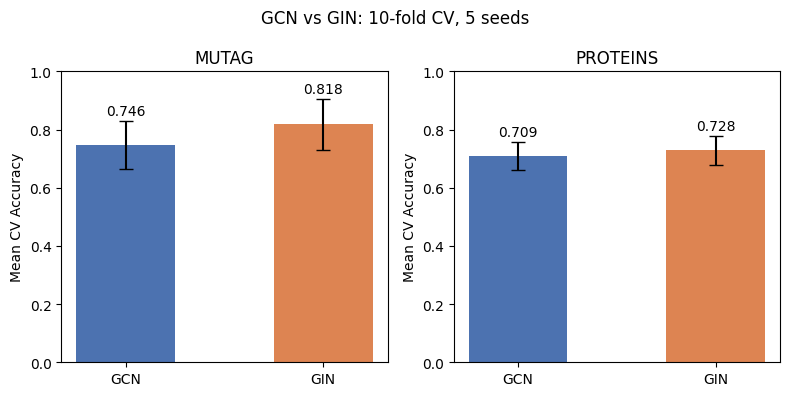

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
models = ['GCN', 'GIN']
colors = ['#4C72B0', '#DD8452']

for i, ds_name in enumerate(['MUTAG', 'PROTEINS']):
    subset = df[df['Dataset'] == ds_name].reset_index()
    means  = subset['Mean Acc'].values
    stds   = subset['Std'].values
    bars   = axes[i].bar(models, means, color=colors,
                         width=0.5, yerr=stds, capsize=5)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(ds_name)
    axes[i].set_ylabel('Mean CV Accuracy')
    for bar, m, s in zip(bars, means, stds):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     m + s + 0.02,
                     f'{m:.3f}', ha='center', fontsize=10)

plt.suptitle('GCN vs GIN: 10-fold CV, 5 seeds', fontsize=12)
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()